# E0 298: LAA 2024 Assignment 6

## 1. Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations_with_replacement
from time import time
import pickle
from typing import Tuple, List


### i. a. Load data from files

In [2]:
def load_data(filename):
    """Load comma-separated data and extract dimensions from first line"""
    with open(filename, 'r') as f:
        # Read dimensions from first line
        n_features, n_targets = map(int, f.readline().strip().split())
        # Read the rest as comma-separated values
        data = np.array([list(map(float, line.strip().split(',')))
                        for line in f.readlines()])

    X = data[:, :n_features]
    y = data[:, -n_targets:]
    return X, y


def load_constraints(filename):
    """Load comma-separated constraints with dimensions from first line"""
    with open(filename, 'r') as f:
        # Read dimensions from first line
        n_constraints, n_features, _ = map(int, f.readline().strip().split())
        lines = f.readlines()

        # Read A matrix (first n_constraints lines)
        A = np.array([list(map(float, line.strip().split(',')))
                     for line in lines[:n_constraints]])

        # Read b vector (next n_constraints lines)
        b = np.array([float(line.strip())
                     for line in lines[n_constraints:n_constraints*2]])

    return A, b

### i. b. Generate degree $n$ polynomial features

In [3]:
def generate_polynomial_features(X, degree):
    """Generate polynomial features up to specified degree"""
    n_samples, n_features = X.shape

    # Start with bias term
    features = [np.ones(n_samples)]

    # Add features for each degree
    for d in range(1, degree + 1):
        combinations = combinations_with_replacement(range(n_features), d)
        for combo in combinations:
            new_feature = np.ones(n_samples)
            for feat_idx in combo:
                new_feature *= X[:, feat_idx]
            features.append(new_feature)

    return np.column_stack(features)

### ii. Train-Test Split

In [4]:
def train_test_split(X, y, test_size=0.2, random_seed=None):
    """
    Split arrays into random train and test subsets.
    
    Parameters:
    -----------
    X : numpy array of shape (n_samples, n_features)
        Features data
    y : numpy array of shape (n_samples, n_targets)
        Target data
    test_size : float
        Proportion of the dataset to include in the test split
    random_seed : int
        Random seed for reproducibility
        
    Returns:
    --------
    X_train, X_test, y_train, y_test : numpy arrays
    """
    if random_seed is not None:
        np.random.seed(random_seed)

    n_samples = X.shape[0]
    n_test = int(n_samples * test_size)

    # Generate random indices
    indices = np.random.permutation(n_samples)
    test_indices = indices[:n_test]
    train_indices = indices[n_test:]

    # Split the data
    X_train = X[train_indices]
    X_test = X[test_indices]
    y_train = y[train_indices]
    y_test = y[test_indices]

    return X_train, X_test, y_train, y_test


### iii. Metrics

In [5]:
def pearson_correlation(x, y):
    """Calculate Pearson correlation coefficient using NumPy"""
    x_mean, y_mean = np.mean(x), np.mean(y)
    x_std, y_std = np.std(x, ddof=1), np.std(y, ddof=1)
    return np.mean((x - x_mean) * (y - y_mean)) / (x_std * y_std)


def mse(y_true, y_pred):
    """Calculate Mean Squared Error"""
    return np.mean((y_true - y_pred) ** 2)


def mae(y_true, y_pred):
    """Calculate Mean Absolute Error"""
    return np.mean(np.abs(y_true - y_pred))

### iv. a. Multi-Linear Regression

In [6]:
def multilinear_regression(X_train, y_train, X_test):
    """Implement multilinear regression using normal equation with train-test split"""
    X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
    X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

    beta = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train
    y_pred_test = X_test_b @ beta
    return y_pred_test, beta

### iv. b. Regression with Polynomial kernel

In [7]:
def polynomial_regression(X_train, y_train, X_test, degree):
    """Implement polynomial regression with given degree and train-test split"""
    Z_train = generate_polynomial_features(X_train, degree)
    Z_test = generate_polynomial_features(X_test, degree)

    beta = np.linalg.inv(Z_train.T @ Z_train) @ Z_train.T @ y_train
    y_pred_test = Z_test @ beta
    return y_pred_test, beta, Z_test.shape[1]

### iv. c. Multi-Linear Regression with Linear Constraints

In [8]:
def constrained_regression(X_train, y_train, X_test, A, b):
    """Implement constrained regression with train-test split"""
    X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
    X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]
    n_features = X_train_b.shape[1]
    n_constraints = A.shape[0]

    A_augmented = np.column_stack([np.zeros(n_constraints), A])
    Q = X_train_b.T @ X_train_b
    top_block = np.block([
        [Q, -A_augmented.T],
        [A_augmented, np.zeros((n_constraints, n_constraints))]
    ])

    solutions = []
    for i in range(y_train.shape[1]):
        y_i = y_train[:, i:i+1]
        X_y = X_train_b.T @ y_i
        rhs = np.concatenate([X_y, b.reshape(-1, 1)])
        solution = np.linalg.solve(top_block, rhs)
        beta = solution[:n_features]
        solutions.append(beta)

    beta = np.column_stack(solutions)
    y_pred_test = X_test_b @ beta
    return y_pred_test, beta

### v. Evaluate Metrics

In [9]:
def calculate_metrics(y_true, y_pred):
    """Calculate correlation, MSE, and MAE"""
    metrics = []
    for i in range(y_true.shape[1]):
        corr = pearson_correlation(y_true[:, i], y_pred[:, i])
        mse_val = mse(y_true[:, i], y_pred[:, i])
        mae_val = mae(y_true[:, i], y_pred[:, i])
        metrics.append((corr, mse_val, mae_val))
    return metrics

### vi. Correlation Plots

In [10]:
def plot_correlation(y_true, y_pred, metrics, title):
    """Create correlation plots for each dimension"""
    n_dims = y_true.shape[1]
    fig, axes = plt.subplots(1, n_dims, figsize=(5*n_dims, 5))
    if n_dims == 1:
        axes = [axes]
    fig.suptitle(title)

    for i, (ax, (corr, mse_val, mae_val)) in enumerate(zip(axes, metrics)):
        ax.scatter(y_true[:, i], y_pred[:, i], alpha=0.5)

        # Add diagonal line
        lims = [
            np.min([ax.get_xlim(), ax.get_ylim()]),
            np.max([ax.get_xlim(), ax.get_ylim()]),
        ]
        ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0)

        # Add regression line
        coeffs = np.polyfit(y_true[:, i], y_pred[:, i], 1)
        poly = np.poly1d(coeffs)
        ax.plot(y_true[:, i], poly(y_true[:, i]), "r-", alpha=0.75)

        ax.set_xlabel('Actual y{}'.format(i+1))
        ax.set_ylabel('Predicted y{}'.format(i+1))
        ax.set_title('Dimension {}\nr={:.3f}, RMSE={:.3f}, MAE={:.3f}'.format(
            i+1, corr, np.sqrt(mse_val), mae_val))

    plt.tight_layout()
    plt.show()

### Regression-Main


Part 1: Multilinear Regression
Data loaded: X shape=(10000, 10), y shape=(10000, 3)
Train set: X=(8000, 10), y=(8000, 3)
Test set: X=(2000, 10), y=(2000, 3)

Multilinear Regression Results (Test Set):
Dimension 1:
  Correlation: 0.999
  RMSE: 0.199
  MAE: 0.159
Dimension 2:
  Correlation: 0.999
  RMSE: 0.195
  MAE: 0.156
Dimension 3:
  Correlation: 0.999
  RMSE: 0.203
  MAE: 0.164


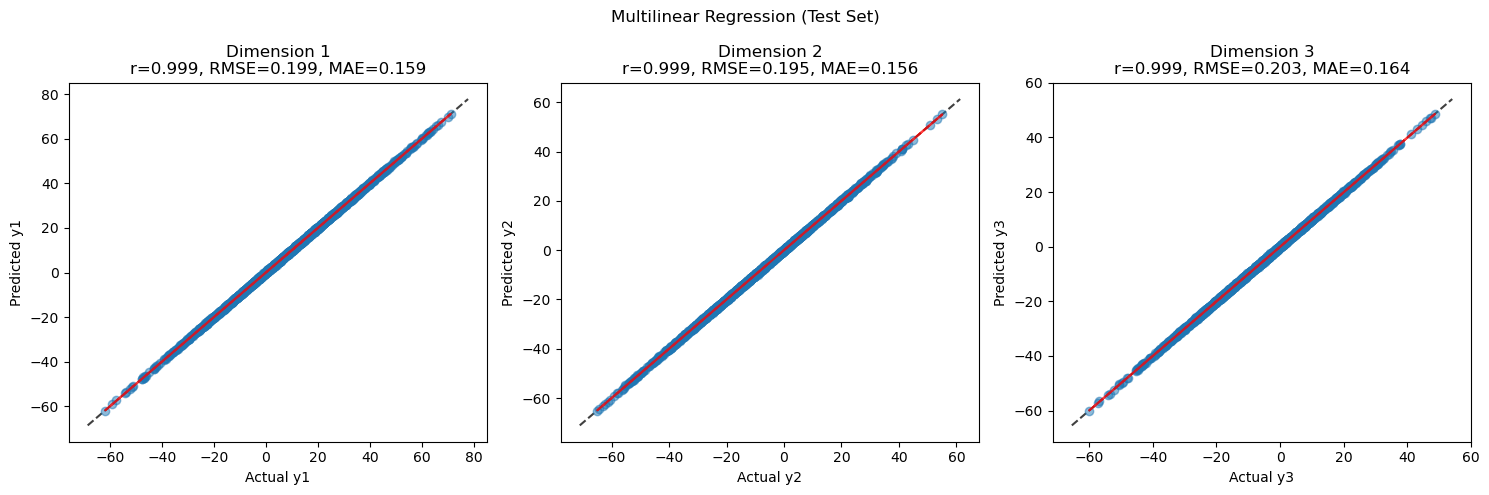


Part 2: Polynomial Regression
Data loaded: X shape=(10000, 2), y shape=(10000, 3)

Trying polynomial regression with degree 2
Number of features after transformation: 6
Dimension 1:
  Correlation: 0.9958885515256186
  RMSE: 0.09921916574608367
  MAE: 0.07853052035686198
Dimension 2:
  Correlation: 0.9959364638567914
  RMSE: 0.09921750758367225
  MAE: 0.07883286403203271
Dimension 3:
  Correlation: 0.994805962212011
  RMSE: 0.09760776822130132
  MAE: 0.0777977356976211

Trying polynomial regression with degree 3
Number of features after transformation: 10
Dimension 1:
  Correlation: 0.9958870996724637
  RMSE: 0.09923840566864645
  MAE: 0.07857552783662121
Dimension 2:
  Correlation: 0.9959361954654754
  RMSE: 0.09922132970925755
  MAE: 0.07884011465062964
Dimension 3:
  Correlation: 0.9947950223850753
  RMSE: 0.09772121829593282
  MAE: 0.07791240267499984

Trying polynomial regression with degree 4
Number of features after transformation: 15
Dimension 1:
  Correlation: 0.99588399311238

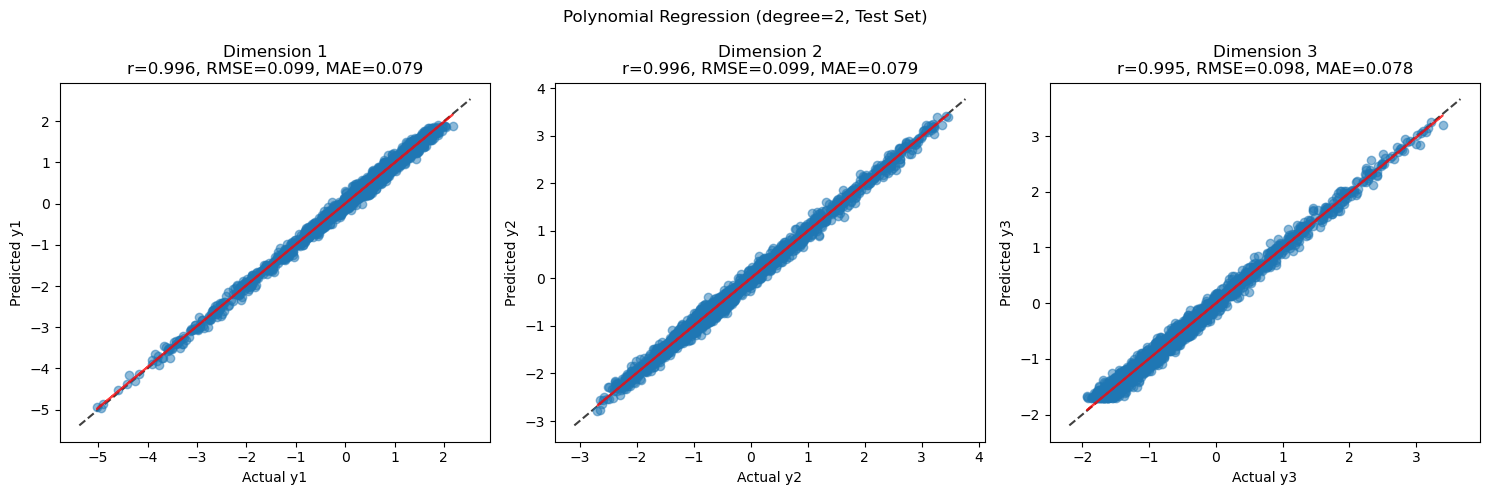


Part 3: Constrained Regression
Constraints loaded: A shape=(3, 10), b shape=(3,)
(11, 3)

Constrained Regression Results (Test Set):
Dimension 1:
  Correlation: 0.935
  RMSE: 7.299
  MAE: 5.740
Dimension 2:
  Correlation: 0.815
  RMSE: 10.738
  MAE: 8.575
Dimension 3:
  Correlation: 0.919
  RMSE: 6.677
  MAE: 5.332


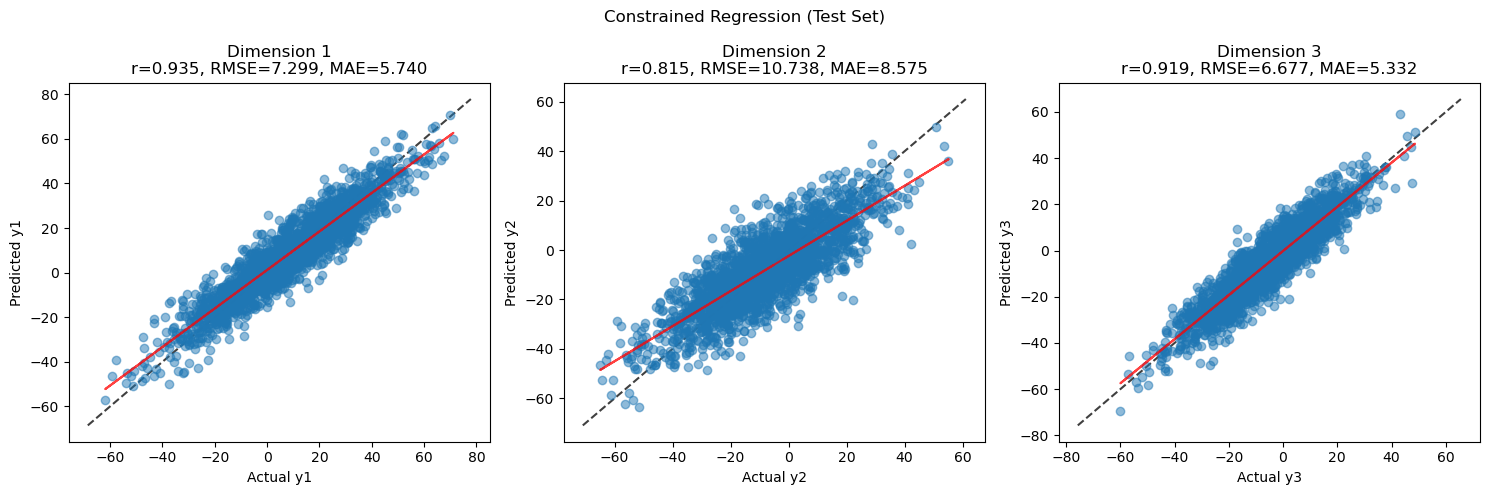


Constraint Satisfaction Check:

Target 1 constraint violations:
Maximum: 4.62e-14
Mean: 1.54e-14
Individual constraints:
  Constraint 1: |Ax - b| = 0.00e+00 (b = 4.56e+01)
  Constraint 2: |Ax - b| = 0.00e+00 (b = -7.84e+01)
  Constraint 3: |Ax - b| = 4.62e-14 (b = 2.63e+01)

Target 2 constraint violations:
Maximum: 2.84e-14
Mean: 2.13e-14
Individual constraints:
  Constraint 1: |Ax - b| = 2.13e-14 (b = 4.56e+01)
  Constraint 2: |Ax - b| = 2.84e-14 (b = -7.84e+01)
  Constraint 3: |Ax - b| = 1.42e-14 (b = 2.63e+01)

Target 3 constraint violations:
Maximum: 2.13e-14
Mean: 1.66e-14
Individual constraints:
  Constraint 1: |Ax - b| = 2.13e-14 (b = 4.56e+01)
  Constraint 2: |Ax - b| = 1.42e-14 (b = -7.84e+01)
  Constraint 3: |Ax - b| = 1.42e-14 (b = 2.63e+01)


In [12]:
def regr_main():
    # Set random seed for reproducibility
    np.random.seed(42)

    # Part 1: Multilinear Regression
    print("\nPart 1: Multilinear Regression")
    X, y = load_data('lin_regression_txt/regression_data_003.txt')
    print(f"Data loaded: X shape={X.shape}, y shape={y.shape}")

    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_seed=42)
    print(f"Train set: X={X_train.shape}, y={y_train.shape}")
    print(f"Test set: X={X_test.shape}, y={y_test.shape}")

    y_pred_test, beta = multilinear_regression(X_train, y_train, X_test)
    metrics = calculate_metrics(y_test, y_pred_test)

    print("\nMultilinear Regression Results (Test Set):")
    for i, (corr, mse_val, mae_val) in enumerate(metrics):
        print(f"Dimension {i+1}:")
        print(f"  Correlation: {corr:.3f}")
        print(f"  RMSE: {np.sqrt(mse_val):.3f}")
        print(f"  MAE: {mae_val:.3f}")

    plot_correlation(y_test, y_pred_test, metrics,
                     "Multilinear Regression (Test Set)")

    # Part 2: Polynomial Regression
    print("\nPart 2: Polynomial Regression")
    X_poly, y_poly = load_data(
        'poly_regression_txt/poly_regression_data_003.txt')
    print(f"Data loaded: X shape={X_poly.shape}, y shape={y_poly.shape}")

    # Split polynomial data
    X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
        X_poly, y_poly, test_size=0.2, random_seed=42)

    best_metrics = None
    best_degree = None
    best_predictions = None
    best_avg_corr = -np.inf

    for degree in range(2, 5):
        print(f"\nTrying polynomial regression with degree {degree}")
        y_pred_test_poly, beta_poly, n_features = polynomial_regression(
            X_train_poly, y_train_poly, X_test_poly, degree)
        metrics_poly = calculate_metrics(y_test_poly, y_pred_test_poly)

        print(f"Number of features after transformation: {n_features}")
        for i, (corr, mse_val, mae_val) in enumerate(metrics_poly):
            print(f"Dimension {i+1}:")
            print(f"  Correlation: {corr}")
            print(f"  RMSE: {np.sqrt(mse_val)}")
            print(f"  MAE: {mae_val}")

        avg_corr = np.mean([m[0] for m in metrics_poly])
        if avg_corr > best_avg_corr:
            best_avg_corr = avg_corr
            best_metrics = metrics_poly
            best_degree = degree
            best_predictions = y_pred_test_poly

    print(f"\nBest polynomial degree: {best_degree}")
    plot_correlation(y_test_poly, best_predictions, best_metrics,
                     f"Polynomial Regression (degree={best_degree}, Test Set)")

    # Part 3: Constrained Regression
    print("\nPart 3: Constrained Regression")
    try:
        # Load constraints
        A, b = load_constraints('constraints_txt/constraints_003.txt')
        print(f"Constraints loaded: A shape={A.shape}, b shape={b.shape}")

        # Split data and perform constrained regression
        y_pred_test_const, beta = constrained_regression(
            X_train, y_train, X_test, A, b)
        metrics_const = calculate_metrics(y_test, y_pred_test_const)
        
        print(beta.shape)

        print("\nConstrained Regression Results (Test Set):")
        for i, (corr, mse_val, mae_val) in enumerate(metrics_const):
            print(f"Dimension {i+1}:")
            print(f"  Correlation: {corr:.3f}")
            print(f"  RMSE: {np.sqrt(mse_val):.3f}")
            print(f"  MAE: {mae_val:.3f}")

        plot_correlation(y_test, y_pred_test_const, metrics_const,
                         "Constrained Regression (Test Set)")

        # Check constraint satisfaction
        print("\nConstraint Satisfaction Check:")
        for i in range(beta.shape[1]):
            error = np.abs(A @ beta[1:, i] - b)  # Exclude bias term
            print(f"\nTarget {i+1} constraint violations:")
            print(f"Maximum: {np.max(error):.2e}")
            print(f"Mean: {np.mean(error):.2e}")
            print("Individual constraints:")
            for j, (err, constraint) in enumerate(zip(error, b)):
                print(
                    f"  Constraint {j+1}: |Ax - b| = {err:.2e} (b = {constraint:.2e})")

    except Exception as e:
        print(f"Error in constrained regression: {str(e)}")
        raise
    
regr_main()

## 2. PCA (Image Compression)

### i. Centre Data

In [70]:
def standardize_data(X: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Center the data matrix by subtracting the mean.
    
    Args:
        X: Input data matrix of shape (n_samples, n_features)
    
    Returns:
        Tuple of (centered_data, mean)
    """
    mean = np.mean(X, axis=0)
    centered_data = X - mean
    return centered_data, mean

### ii. Covariance matrix & Eigen Decomposition 

In [71]:
def compute_pca_eigen(X: np.ndarray, n_components: int) -> Tuple[np.ndarray, np.ndarray, List[float]]:
    """
    Perform eigen decomposition of the covariance matrix.
    
    Args:
        X: Centered input data matrix of shape (n_samples, n_features)
        n_components: Number of principal components to compute
    
    Returns:
        Tuple of (principal_components, transformed_data, explained_variance_ratios)
    """
    # Compute covariance matrix
    cov_matrix = np.cov(X.T)

    # Compute eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    # Sort eigenvalues and eigenvectors in descending order
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # Select top n_components
    principal_components = eigenvectors[:, :n_components]

    # Transform data
    transformed_data = X @ principal_components

    # Calculate explained variance ratios
    total_variance = np.sum(eigenvalues)
    explained_variance_ratios = [
        val / total_variance for val in eigenvalues[:n_components]]

    return principal_components, transformed_data, explained_variance_ratios

### iii. Reconstruct images

In [72]:
def reconstruct_images(X: np.ndarray, components: np.ndarray, mean: np.ndarray) -> np.ndarray:
    """
    Reconstruct images using computed components.
    
    Args:
        X: Transformed data matrix
        components: Principal components
        mean: Original data mean
    
    Returns:
        Reconstructed data matrix
    """
    reconstructed = X @ components.T
    reconstructed = reconstructed + mean
    return reconstructed

### iv. PCA class

In [73]:
class PCA:
    def __init__(self, n_components: int):
        self.n_components = n_components
        self.components = None
        self.mean = None
        self.explained_variance_ratios = None

    def fit(self, X: np.ndarray):
        """Fit PCA model to training data."""
        # Standardize data
        X_centered, self.mean = standardize_data(X)

        # Compute PCA
        self.components, _, self.explained_variance_ratios = compute_pca_eigen(
            X_centered, self.n_components
        )
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        """Transform data using fitted components."""
        X_centered = X - self.mean
        return X_centered @ self.components

    def inverse_transform(self, X_transformed: np.ndarray) -> np.ndarray:
        """Reconstruct original data from transformed data."""
        return reconstruct_images(X_transformed, self.components, self.mean)

### v. Calculate MSE & PSNR

In [74]:
def calculate_metrics(original: np.ndarray, reconstructed: np.ndarray) -> Tuple[float, float]:
    """
    Calculate MSE and PSNR metrics.
    
    Args:
        original: Original images
        reconstructed: Reconstructed images
    
    Returns:
        Tuple of (mse, psnr)
    """
    mse = np.mean((original - reconstructed) ** 2)
    psnr = 20 * np.log10(255.0 / np.sqrt(mse))
    return mse, psnr

### vi. Load & Preprocess data

In [75]:
def unpickle(file):
    """Load CIFAR-10 batch file."""
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict


def load_and_preprocess_mnist():
    """Load and preprocess MNIST dataset from CSV files."""
    # Load training data
    train_data = np.loadtxt('mnist/mnist_train.csv', delimiter=',', skiprows=1)
    X_train = train_data[:, 1:] / 255.0  # Scale to [0, 1]
    y_train = train_data[:, 0]

    # Load test data
    test_data = np.loadtxt('mnist/mnist_test.csv', delimiter=',', skiprows=1)
    X_test = test_data[:, 1:] / 255.0  # Scale to [0, 1]
    y_test = test_data[:, 0]

    return X_train, y_train, X_test, y_test


def load_and_preprocess_cifar10():
    """Load and preprocess CIFAR-10 dataset from batch files."""
    # Load training batches
    X_train = []
    y_train = []
    for i in range(1, 6):
        batch = unpickle(f'cifar-10/data_batch_{i}')
        X_train.append(batch[b'data'])
        y_train.extend(batch[b'labels'])

    X_train = np.vstack(X_train)
    y_train = np.array(y_train)

    # Load test batch
    test_batch = unpickle('cifar-10/test_batch')
    X_test = test_batch[b'data']
    y_test = np.array(test_batch[b'labels'])

    # Reshape and normalize data
    X_train = X_train.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1) / 255.0
    X_test = X_test.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1) / 255.0

    return X_train, y_train, X_test, y_test

### vii. Plot reconstructions

In [76]:
def plot_all_reconstructions(original_examples, reconstructed_dict, labels, dataset_name):
    """
    Plot original and reconstructed images for all n_components in one figure.
    
    Args:
        original_examples: Original images
        reconstructed_dict: Dictionary of reconstructed images for each n_components
        labels: Class labels
        dataset_name: Name of the dataset
    """
    n_images = len(original_examples)
    n_components_list = sorted(reconstructed_dict.keys())

    # Create figure with subplots
    fig, axes = plt.subplots(n_images, len(n_components_list) + 1,
                             figsize=(3*(len(n_components_list) + 1), 2*n_images))
    fig.suptitle(f'{dataset_name} Reconstruction Examples across Different Components',
                 fontsize=14, y=1.02)

    # Set background color
    plt.rcParams['figure.facecolor'] = 'white'

    # Plot original images in first column
    for idx in range(n_images):
        if len(original_examples[idx].shape) == 3:  # Color image
            axes[idx, 0].imshow(original_examples[idx])
        else:  # Grayscale image
            axes[idx, 0].imshow(original_examples[idx], cmap='gray')
        axes[idx, 0].set_title(f'Original\n{labels[idx]}' if idx == 0 else labels[idx],
                               color='blue' if dataset_name == 'MNIST' else 'red')
        axes[idx, 0].axis('off')

    # Plot reconstructed images
    for col, n_comp in enumerate(n_components_list, 1):
        reconstructed = reconstructed_dict[n_comp]
        for idx in range(n_images):
            if len(reconstructed[idx].shape) == 3:  # Color image
                axes[idx, col].imshow(reconstructed[idx])
            else:  # Grayscale image
                axes[idx, col].imshow(reconstructed[idx], cmap='gray')
            title_color = 'blue' if dataset_name == 'MNIST' else 'red'
            axes[idx, col].set_title(
                f'n={n_comp}' if idx == 0 else '', color=title_color)
            axes[idx, col].axis('off')

    plt.tight_layout()
    plt.savefig(f'{dataset_name.lower()}_reconstructions.png',
                dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    plt.show()
    plt.close()

### viii. Plot quality compression tradeoff

In [77]:
def plot_quality_compression_tradeoff(results_dict):
    """Plot quality vs compression trade-off analysis including compression ratio."""
    datasets = list(results_dict.keys())
    n_components_list = results_dict[datasets[0]]['n_components']

    # Create figure with subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

    colors = {'MNIST': 'blue', 'CIFAR-10': 'red'}

    # Plot MSE
    for dataset in datasets:
        ax1.plot(n_components_list, results_dict[dataset]['mse'],
                 marker='o', label=dataset, color=colors[dataset], linewidth=2)
    ax1.set_xlabel('Number of Components')
    ax1.set_ylabel('Mean Squared Error')
    ax1.set_title('MSE vs Number of Components')
    ax1.legend()
    # ax1.grid(True)

    # Plot PSNR
    for dataset in datasets:
        ax2.plot(n_components_list, results_dict[dataset]['psnr'],
                 marker='o', label=dataset, color=colors[dataset], linewidth=2)
    ax2.set_xlabel('Number of Components')
    ax2.set_ylabel('PSNR (dB)')
    ax2.set_title('PSNR vs Number of Components')
    ax2.legend()
    # ax2.grid(True)

    # Plot Compression Ratio
    for dataset in datasets:
        orig_dims = np.prod(results_dict[dataset]['original_dims'])
        compression_ratios = [orig_dims /
                              n_comp for n_comp in n_components_list]
        ax3.plot(n_components_list, compression_ratios,
                 marker='o', label=dataset, color=colors[dataset], linewidth=2)
    ax3.set_xlabel('Number of Components')
    ax3.set_ylabel('Compression Ratio (original:compressed)')
    ax3.set_title('Compression Ratio vs Number of Components')
    ax3.legend()
    # ax3.grid(True)

    plt.suptitle('Quality vs Compression Trade-off Analysis',
                 fontsize=14, y=1.05)
    plt.tight_layout()
    plt.savefig('quality_compression_tradeoff.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

### ix. Print tradeoff table

In [78]:
def print_quality_table(results_dict):
    """Print quality metrics table."""
    datasets = list(results_dict.keys())
    n_components_list = results_dict[datasets[0]]['n_components']

    # Print header
    print("\nQuality vs Compression Trade-off Analysis")
    print("=" * 80)
    header = "| {:<12} | ".format("Components")
    for dataset in datasets:
        header += "{:<15} {:<15} |".format(f"{dataset} MSE", f"{dataset} PSNR")
    print(header)
    print("-" * 80)

    # Print data rows
    for i, n_comp in enumerate(n_components_list):
        row = "| {:<12} |".format(n_comp)
        for dataset in datasets:
            row += " {:<15.4f} {:<15.2f} |".format(
                results_dict[dataset]['mse'][i],
                results_dict[dataset]['psnr'][i]
            )
        print(row)
    print("=" * 80)

    # Print compression ratios
    print("\nCompression Ratios:")
    for dataset in datasets:
        original_dims = results_dict[dataset]['original_dims']
        total_dims = np.prod(original_dims)
        print(f"\n{dataset}:")
        print(f"Original dimensions: {original_dims} (total: {total_dims})")
        for n_comp in n_components_list:
            ratio = total_dims / n_comp
            print(f"n_components = {n_comp}: {ratio:.2f}:1")

### x. Analyze dataset

In [79]:
def analyze_dataset(X_train, y_train, X_test, y_test, dataset_name, n_components_list=[10, 20, 50, 100, 200]):
    """Analyze PCA reconstruction for a dataset."""
    # Store original shape
    original_shape = X_train.shape[1:] if len(X_train.shape) > 2 else (
        int(np.sqrt(X_train.shape[1])), int(np.sqrt(X_train.shape[1])))

    # Flatten data if needed
    if len(X_train.shape) > 2:
        X_train = X_train.reshape(X_train.shape[0], -1)
        X_test = X_test.reshape(X_test.shape[0], -1)

    # Analysis results
    results = {
        'n_components': n_components_list,
        'mse': [],
        'psnr': [],
        'original_dims': original_shape
    }

    # Store reconstructed examples for each n_components
    reconstructed_dict = {}
    example_indices = []

    # Get one example from each class
    for class_idx in range(10):
        class_indices = np.where(y_test == class_idx)[0]
        if len(class_indices) > 0:
            example_indices.append(class_indices[0])

    # Analyze different numbers of components
    for n_components in n_components_list:
        print(f"Processing {dataset_name} with {n_components} components...")

        # Fit PCA
        pca = PCA(n_components=n_components)
        pca.fit(X_train)

        # Transform and reconstruct test data
        X_transformed = pca.transform(X_test)
        X_reconstructed = pca.inverse_transform(X_transformed)

        # Calculate metrics
        mse, psnr = calculate_metrics(X_test, X_reconstructed)
        results['mse'].append(mse)
        results['psnr'].append(psnr)

        # Store reconstructed examples
        original_examples = X_test[example_indices]
        reconstructed_examples = X_reconstructed[example_indices]

        # Reshape back to image format
        original_examples = original_examples.reshape(-1, *original_shape)
        reconstructed_examples = reconstructed_examples.reshape(
            -1, *original_shape)
        reconstructed_dict[n_components] = reconstructed_examples

    # Get class names
    class_names = {
        'mnist': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'],
        'cifar-10': ['airplane', 'automobile', 'bird', 'cat', 'deer',
                     'dog', 'frog', 'horse', 'ship', 'truck']
    }
    labels = [
        f"{class_names[dataset_name.lower()][int(y_test[i])]}" for i in example_indices]

    # Plot all reconstructions
    plot_all_reconstructions(
        original_examples.reshape(-1, *original_shape),
        reconstructed_dict,
        labels,
        dataset_name
    )

    return results

### xi. PCA_main

Loading and analyzing MNIST dataset...
Processing MNIST with 10 components...
Processing MNIST with 20 components...
Processing MNIST with 50 components...
Processing MNIST with 100 components...
Processing MNIST with 200 components...


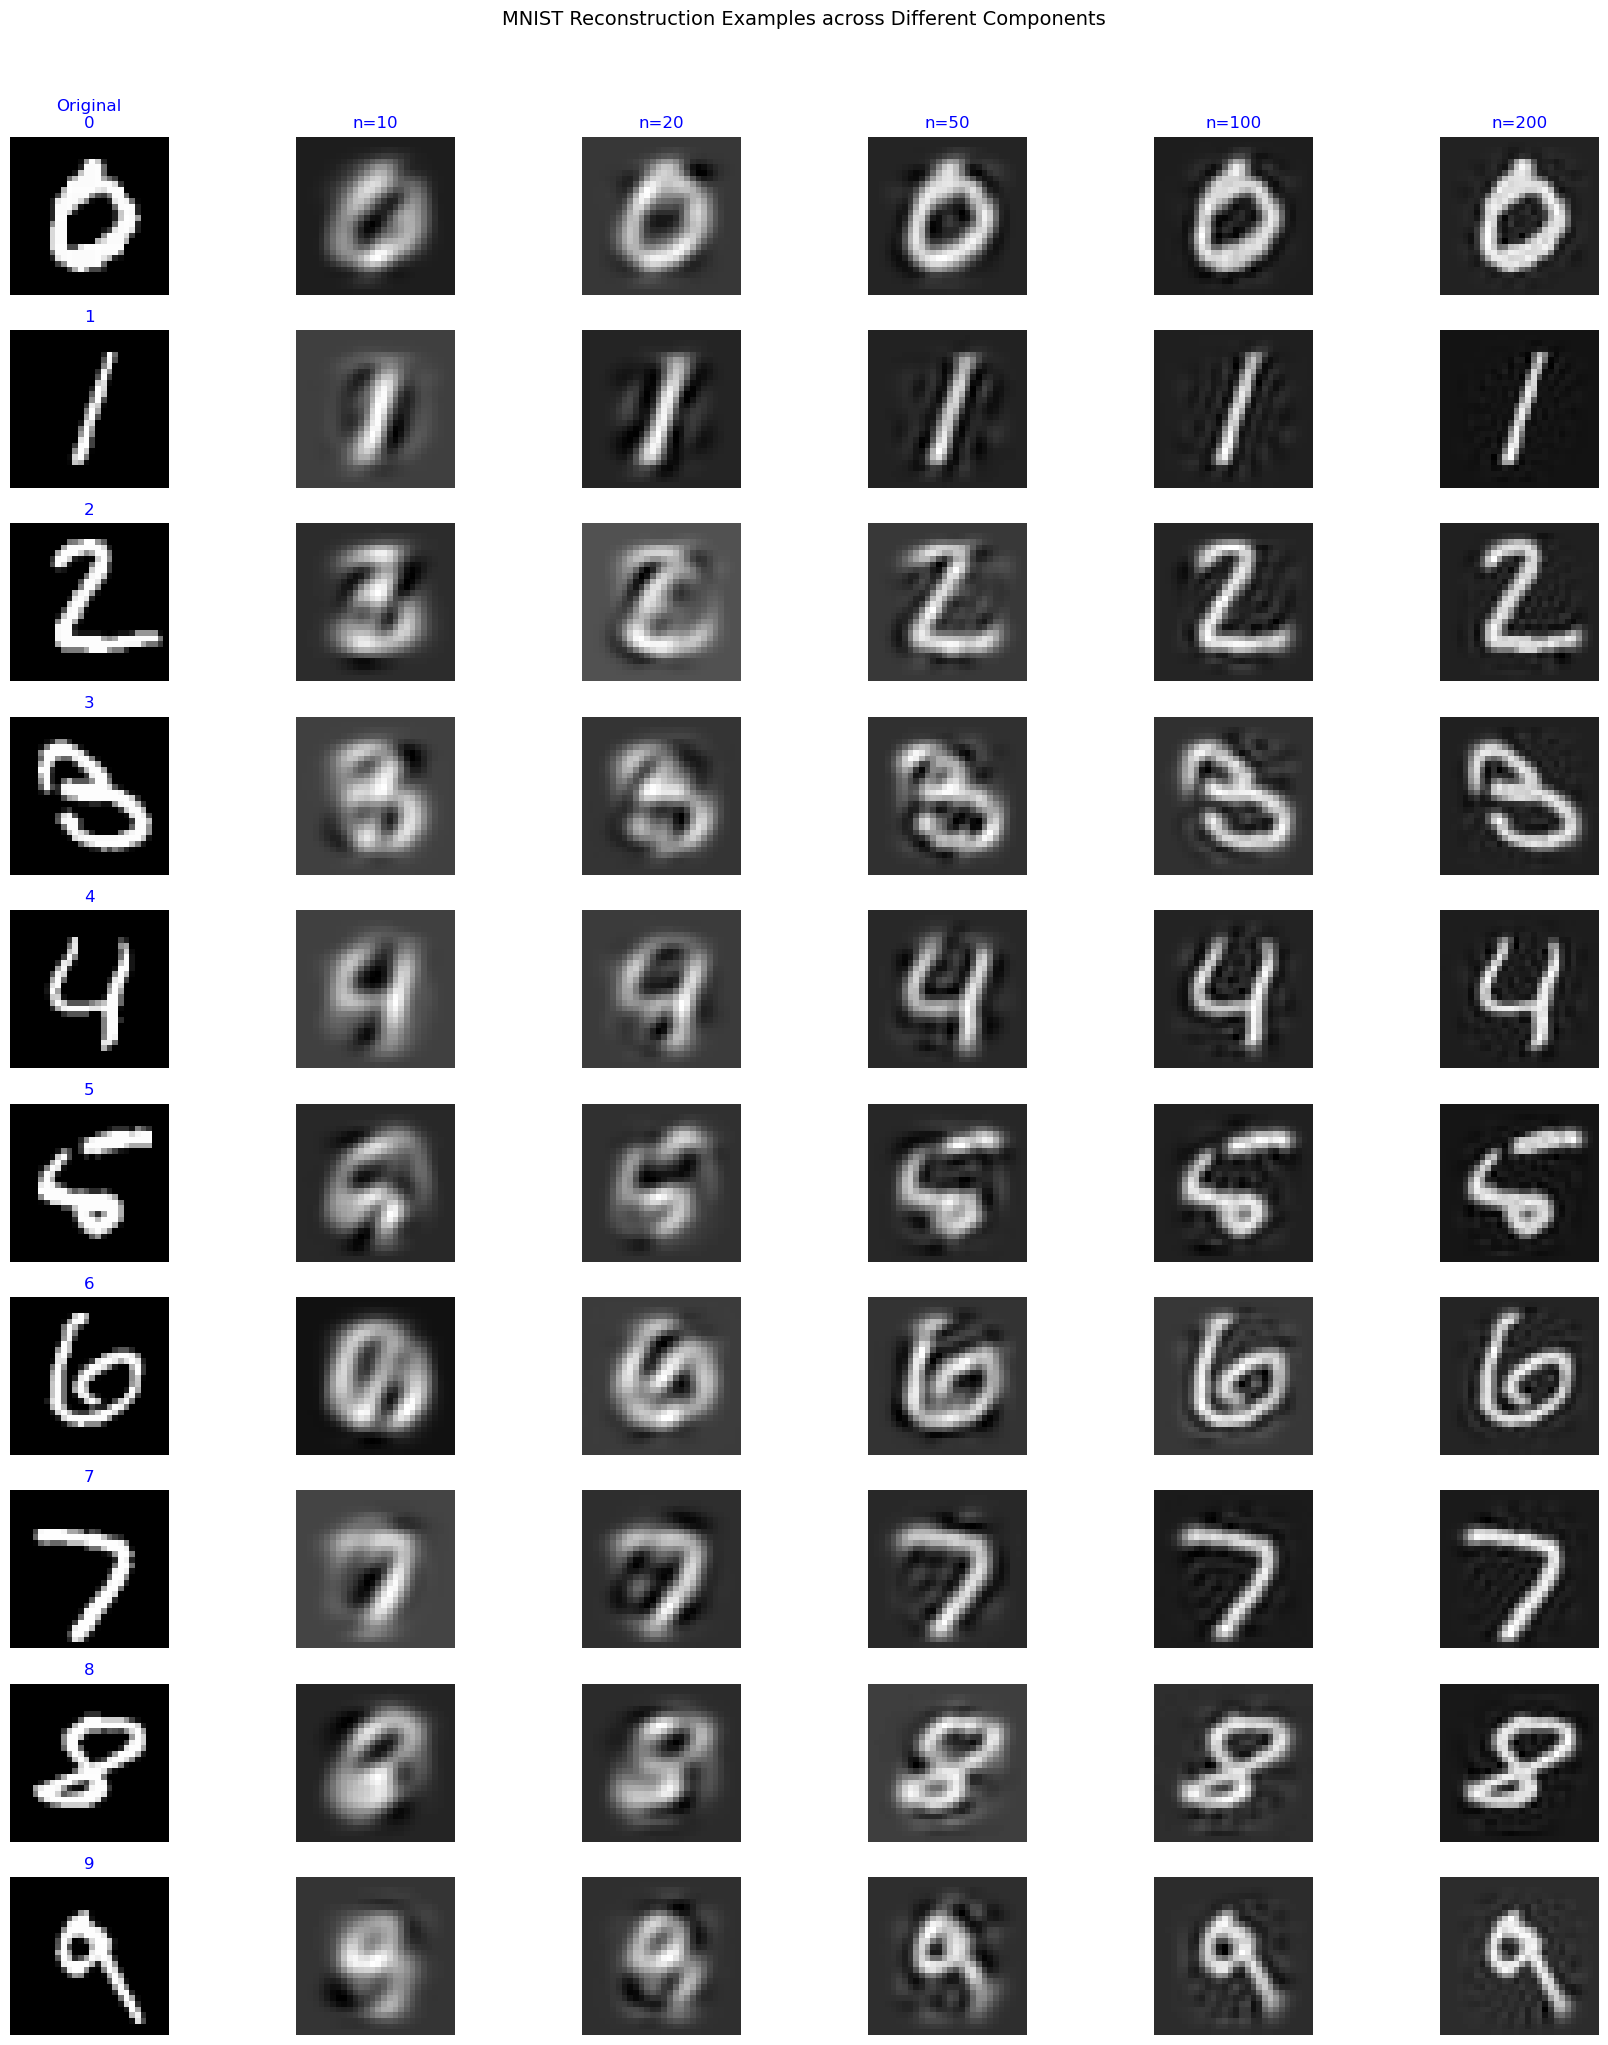


Loading and analyzing CIFAR-10 dataset...
Processing CIFAR-10 with 10 components...
Processing CIFAR-10 with 20 components...
Processing CIFAR-10 with 50 components...
Processing CIFAR-10 with 100 components...
Processing CIFAR-10 with 200 components...


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

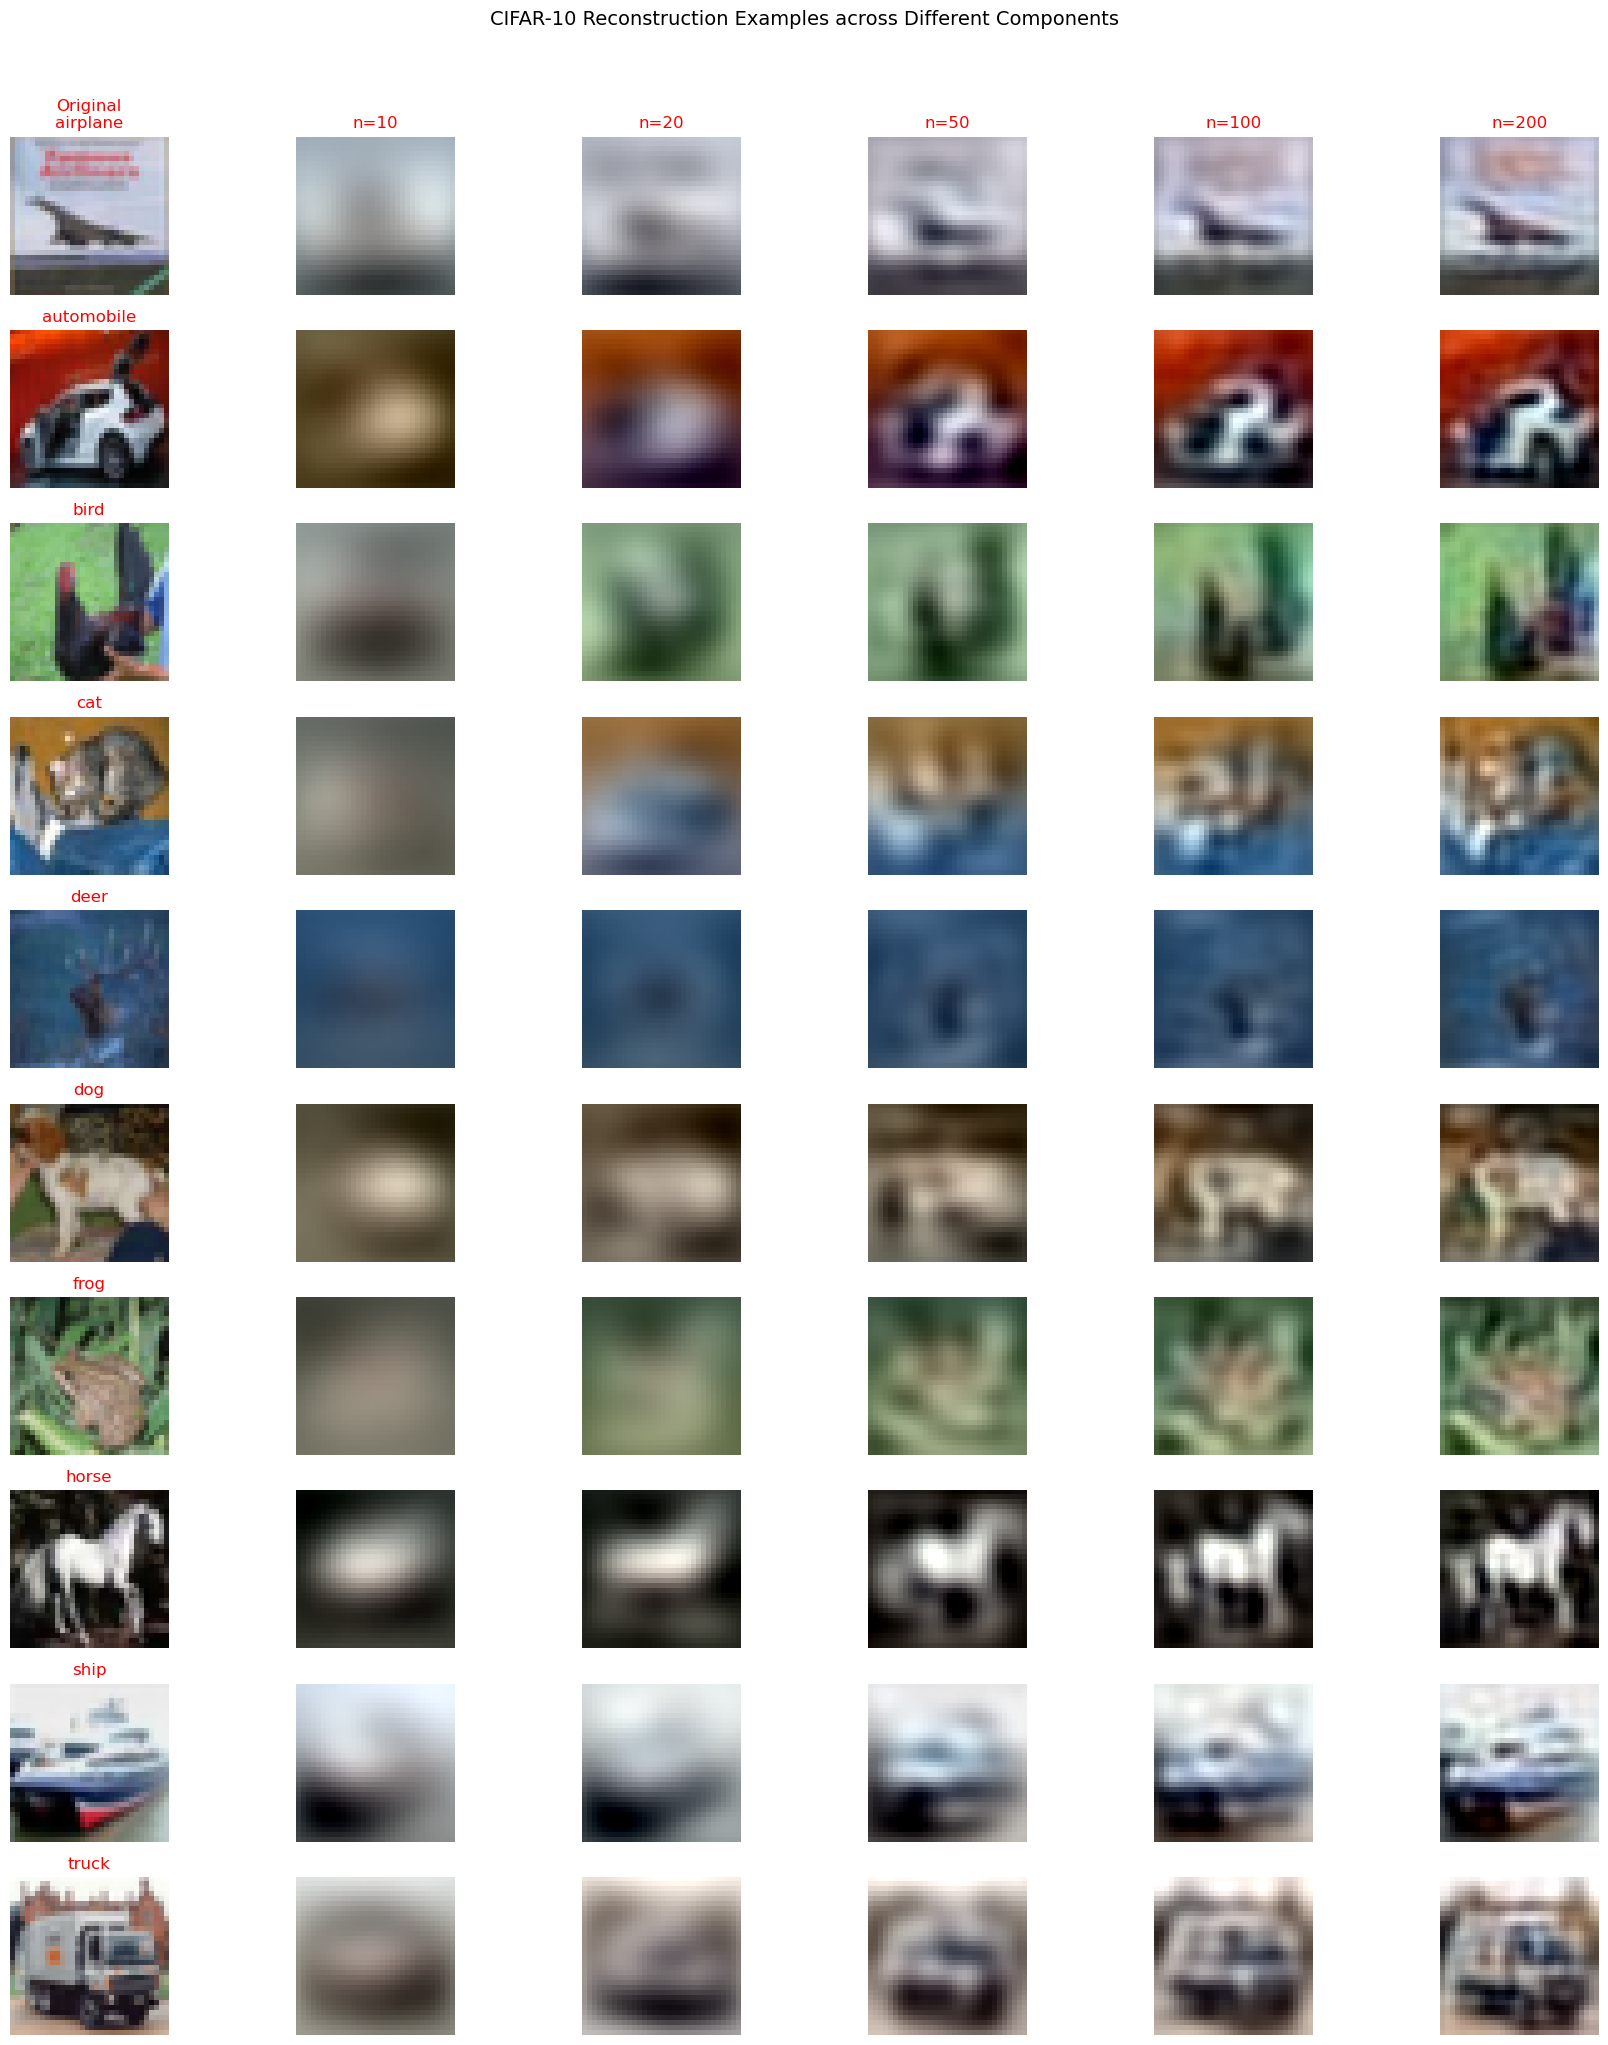

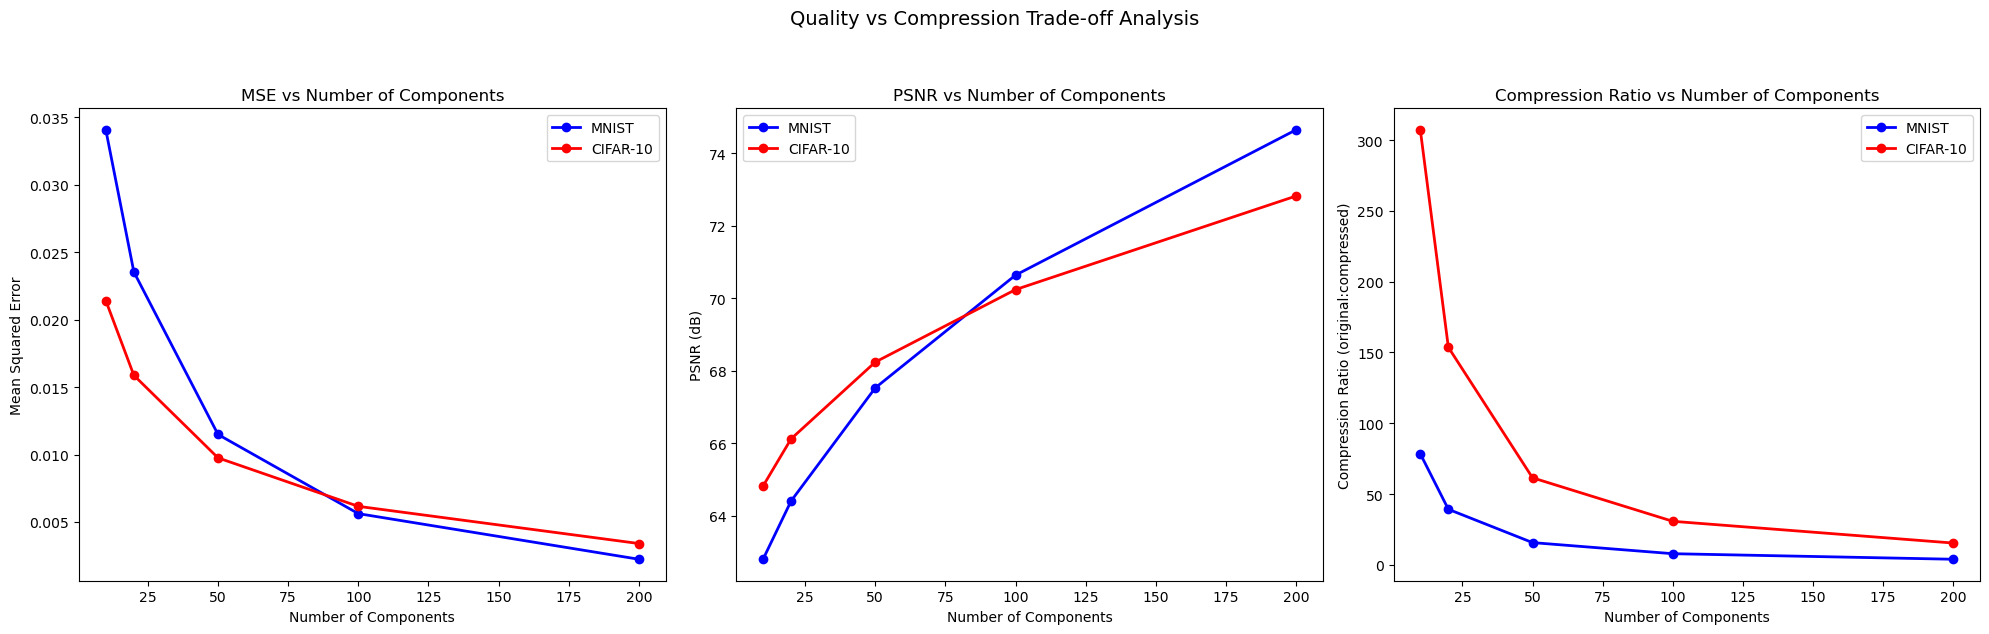


Quality vs Compression Trade-off Analysis
| Components   | MNIST MSE       MNIST PSNR      |CIFAR-10 MSE    CIFAR-10 PSNR   |
--------------------------------------------------------------------------------
| 10           | 0.0341          62.81           | 0.0214          64.82           |
| 20           | 0.0235          64.41           | 0.0159          66.12           |
| 50           | 0.0115          67.53           | 0.0098          68.24           |
| 100          | 0.0056          70.64           | 0.0062          70.24           |
| 200          | 0.0022          74.64           | 0.0034          72.82           |

Compression Ratios:

MNIST:
Original dimensions: (28, 28) (total: 784)
n_components = 10: 78.40:1
n_components = 20: 39.20:1
n_components = 50: 15.68:1
n_components = 100: 7.84:1
n_components = 200: 3.92:1

CIFAR-10:
Original dimensions: (32, 32, 3) (total: 3072)
n_components = 10: 307.20:1
n_components = 20: 153.60:1
n_components = 50: 61.44:1
n_components = 100:

In [80]:
def pca_main():
    # Set random seed for reproducibility
    np.random.seed(42)

    # Define number of components to test
    n_components_list = [10, 20, 50, 100, 200]

    # Store results for both datasets
    results_dict = {}

    # Analyze MNIST
    print("Loading and analyzing MNIST dataset...")
    X_train_mnist, y_train_mnist, X_test_mnist, y_test_mnist = load_and_preprocess_mnist()
    results_dict['MNIST'] = analyze_dataset(
        X_train_mnist, y_train_mnist, X_test_mnist, y_test_mnist,
        "MNIST", n_components_list
    )

    # Analyze CIFAR-10
    print("\nLoading and analyzing CIFAR-10 dataset...")
    X_train_cifar, y_train_cifar, X_test_cifar, y_test_cifar = load_and_preprocess_cifar10()
    results_dict['CIFAR-10'] = analyze_dataset(
        X_train_cifar, y_train_cifar, X_test_cifar, y_test_cifar,
        "CIFAR-10", n_components_list
    )

    # Generate quality vs compression trade-off analysis
    plot_quality_compression_tradeoff(results_dict)
    print_quality_table(results_dict)
    
pca_main()

## 3. Stationary Distribution of Markov Chain

### i. Solving linear system of equations

In [81]:
def solve_linear_system(P):
    """Find stationary distribution by solving system of linear equations."""
    size = P.shape[0]
    # Create coefficient matrix A
    A = (P.T - np.eye(size))
    # Replace last row with sum=1 constraint
    A = np.vstack([A[:-1], np.ones(size)])

    # Create b vector
    b = np.zeros(size)
    b[-1] = 1  # For the sum=1 constraint

    # Solve the system
    try:
        pi = np.linalg.solve(A, b)
        return pi
    except np.linalg.LinAlgError:
        return None

### ii. Power method

In [91]:
def power_method(P, max_iter=5000, tol=1e-10):
    """Find stationary distribution using power iteration method."""
    size = P.shape[0]
    pi = np.ones(size) / size  # Initial distribution

    for i in range(max_iter):
        pi_new = pi @ P
        if np.linalg.norm(pi_new - pi, ord=1) < tol:
            return pi_new, i
        pi = pi_new

    return pi, max_iter

### iii. St-Dist-Main

In [92]:
def st_dist_main(P):
    """Generate solutions using both methods for a sample matrix."""
    print("Transition Matrix P:")
    P = P / P.sum(axis=1)[:, np.newaxis]
    print(P)
    print("\nMethod 1: Linear System Solution")
    pi_linear = solve_linear_system(P)
    print(pi_linear)
    print("\nMethod 2: Power Method Solution")
    pi_power, i = power_method(P)
    print(pi_power)
    print("\nVerification:")
    print("1. Row sums of P:", P.sum(axis=1))
    print("2. sum of pi_linear:", pi_linear.sum())
    print("4. sum of pi_power:", pi_power.sum())
    print("5. No. of iterations for power method convergence:", i)
    print("6. π * P = π for linear solution:",
          np.allclose(pi_linear @ P, pi_linear))
    print("7. π * P = π for power method:",
          np.allclose(pi_power @ P, pi_power))
    
    
def load_data(filename):
    """Load comma-separated data and extract dimensions from first line"""
    data = np.loadtxt(filename, delimiter=' ')
    return data


# Show example with one matrix
example_P = load_data("transition_matrices/P_003.txt")
st_dist_main(example_P)

Transition Matrix P:
[[0.0054088  0.00099936 0.00578206 ... 0.01576172 0.01230935 0.00767763]
 [0.00790107 0.00072589 0.00016728 ... 0.00120509 0.0106803  0.01225506]
 [0.01745624 0.00269976 0.01926111 ... 0.01330793 0.00235217 0.00442244]
 ...
 [0.00705035 0.01316803 0.00106592 ... 0.01294507 0.00233389 0.01771612]
 [0.01374182 0.01870532 0.00938745 ... 0.01142861 0.00494312 0.00320011]
 [0.00059872 0.00872458 0.00856507 ... 0.00127729 0.00554055 0.00282146]]

Method 1: Linear System Solution
[0.00934967 0.00968373 0.00890384 0.00998495 0.00973637 0.00988996
 0.01113904 0.01015781 0.01068789 0.00997277 0.01001272 0.01078596
 0.01046032 0.00954613 0.0100021  0.01085646 0.00913685 0.00983034
 0.0101416  0.00999424 0.01021116 0.01105351 0.01046937 0.01004502
 0.00955469 0.00995865 0.0101713  0.0098311  0.01012076 0.0096775
 0.01116701 0.01020682 0.00943383 0.00972195 0.00929172 0.00999255
 0.01086966 0.01013688 0.01007926 0.00973426 0.01067782 0.01066872
 0.0100662  0.01068763 0.01019295

## 4. Spectral Norm of Matrix

### i. Power Method

In [93]:
def power_iteration(G, N_iter):
    """Implementation of Algorithm 1: Power iteration method"""
    m, n = G.shape
    # Initialize random vector
    u = np.random.rand(n)
    sigmas = []

    # Perform power iterations
    for _ in range(N_iter):
        v = G @ u
        v = v / np.linalg.norm(v)
        u = G.T @ v
        u = u / np.linalg.norm(u)
        sigmas.append(abs(np.dot(u, G.T @ v)))
    # sigma1 = np.dot(u, G.T @ v)
    return sigmas

### ii. Gram Method

In [94]:
def gram_iteration(G, N_iter):
    """Implementation of Algorithm 2: Gram iteration method"""
    m, n = G.shape
    r = 0

    # Transpose if n > m
    if n > m:
        G = G.T
    sigmas = []

    # Main iteration loop
    for i in range(N_iter):
        r = 2 * (r + np.log(np.linalg.norm(G, 'fro')))
        G = G / np.linalg.norm(G, 'fro')
        G = G.T @ G
        sigmas.append(np.linalg.norm(G, 'fro') **
                      (2**(-(i+1))) * np.exp(2**(-(i+1)) * r))
    # sigma1 = np.linalg.norm(G, 'fro') ** (2**(-N_iter)) * np.exp(2**(-N_iter) * r)
    return sigmas

### iii. Compare method runs

In [95]:
def compare_methods(G, power_iters=2000, gram_iters=15, num_runs=100):
    """Compare both methods over multiple runs"""
    power_results = np.zeros(power_iters)
    gram_results = np.zeros(gram_iters)
    true_sigma = np.linalg.svd(G, compute_uv=False)[0]  # Reference value

    power_times = []
    gram_times = []

    # Store all runs for individual plotting
    all_power_runs = np.zeros((num_runs, power_iters))
    all_gram_runs = np.zeros((num_runs, gram_iters))

    for run in range(num_runs):
        # Power iteration
        start_time = time()
        current_G = G.copy()
        power_results = np.abs(
            np.array(power_iteration(current_G, power_iters)) - true_sigma)
        power_times.append(time() - start_time)
        all_power_runs[run] = power_results

        # Gram iteration
        start_time = time()
        current_G = G.copy()
        gram_results = np.abs(
            np.array(gram_iteration(current_G, gram_iters)) - true_sigma)
        gram_times.append(time() - start_time)
        all_gram_runs[run] = gram_results

    return np.mean(power_times), np.mean(gram_times), all_power_runs, all_gram_runs

### iv. Plot curves

In [96]:
def plot_results(all_power_runs, all_gram_runs):
    """Create and save the two required plots separately"""

    # Plot 1: Mean and standard deviation
    plt.figure(figsize=(10, 6))

    # Power iteration stats
    power_mean = np.mean(all_power_runs, axis=0)
    power_std = np.std(all_power_runs, axis=0)
    power_iters = np.arange(1, len(power_mean) + 1)

    # Gram iteration stats
    gram_mean = np.mean(all_gram_runs, axis=0)
    gram_std = np.std(all_gram_runs, axis=0)
    gram_iters = np.arange(1, len(gram_mean) + 1)

    # Plot mean and std bands
    plt.fill_between(power_iters, power_mean - power_std, power_mean + power_std,
                     alpha=0.3, color='blue', label='Power iteration ±σ')
    plt.plot(power_iters, power_mean, 'b-', label='Power iteration mean')

    plt.fill_between(gram_iters, gram_mean - gram_std, gram_mean + gram_std,
                     alpha=0.3, color='red', label='Gram iteration ±σ')
    plt.plot(gram_iters, gram_mean, 'r-', label='Gram iteration mean')

    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('|σ_method - σ_ref|')
    plt.title('Convergence with Standard Deviation')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Save plot 1
    # plt.savefig('convergence_with_std.png', dpi=300, bbox_inches='tight')
    plt.close()

    # Plot 2: Individual runs
    plt.figure(figsize=(10, 6))

    # Plot first 10 runs for clarity
    for i in range(min(10, all_power_runs.shape[0])):
        plt.plot(power_iters, all_power_runs[i], 'b-', alpha=0.3)
        plt.plot(gram_iters, all_gram_runs[i], 'r-', alpha=0.3)

    plt.plot([], [], 'b-', label='Power iteration runs')
    plt.plot([], [], 'r-', label='Gram iteration runs')
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel('Iteration')
    plt.ylabel('|σ_method - σ_ref|')
    plt.title('Individual Runs Comparison')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Save plot 2
    # plt.savefig('individual_runs.png', dpi=300, bbox_inches='tight')
    plt.close()

### v. Spectral_Norm_Main 

Average Power Iteration time: 0.2377 seconds
Average Gram Iteration time: 0.0171 seconds


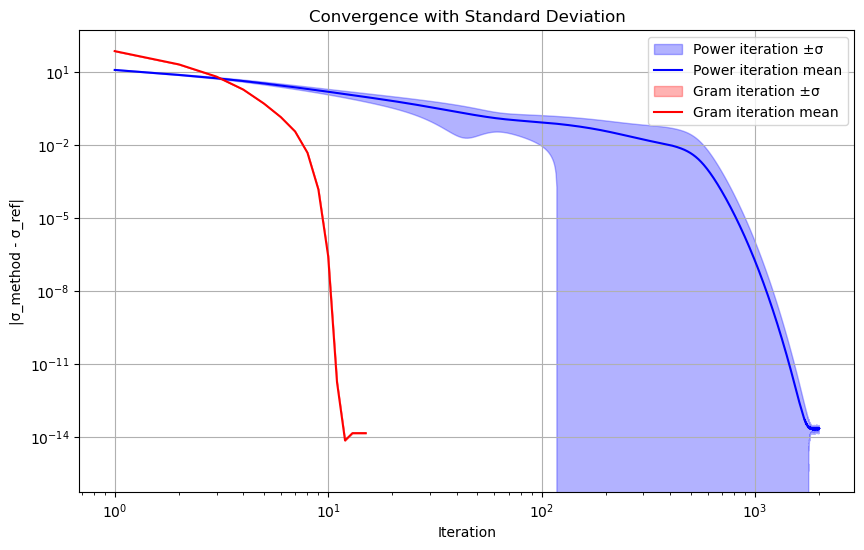

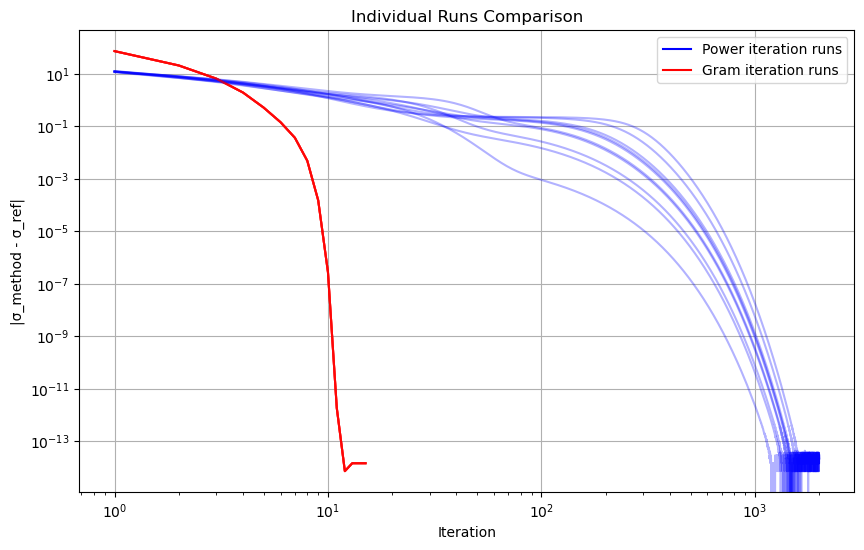

In [101]:
def sp_norm_main():
    # Load the matrix
    G = np.loadtxt('spectral_norm_matrices/matrix_004.txt')

    # Run comparison
    power_time, gram_time, all_power_runs, all_gram_runs = \
        compare_methods(G, power_iters=2000, gram_iters=15, num_runs=100)
        
    random_run_index = np.random.choice(all_power_runs.shape[0])
    
    power_result = all_power_runs[random_run_index]
    gram_result = all_gram_runs[random_run_index]

    # Print timing results
    print(f"Average Power Iteration time: {power_time:.4f} seconds")
    print(f"Average Gram Iteration time: {gram_time:.4f} seconds")

    # Create plots
    plot_results(all_power_runs, all_gram_runs)
    

sp_norm_main()


### vi. Algorithm to calculate min (and max) eigenvalues of a symmetric matrix 

In [98]:
def power_iteration_symm(G, n_iter=1000):
    """
    Implement power iteration as per the algorithm in the image.
    
    Args:
        G: Input matrix
        n_iter: Number of iterations
    
    Returns:
        Normalized eigenvector corresponding to largest eigenvalue
    """
    size = G.shape[0]
    # Initialize random vector
    u = np.random.rand(size)

    # Power iteration
    for _ in range(n_iter):
        # v ← Gu/||Gu||₂
        v = G @ u
        v = v / np.linalg.norm(v)

        # u ← G*v/||G*v||₂
        u = G.T @ v
        u = u / np.linalg.norm(u)

    # Calculate σ₁
    sigma1 = (G @ u) @ v
    return u, sigma1

In [99]:
def min_max_ev(A):
    u, sigma1 = power_iteration_symm(A)
    if u.T @ A @ u < 0:
        print(f"min eig val: {-sigma1}")
        _, sigma2 = power_iteration_symm(A+sigma1*np.eye(3))
        print(f"max eig val: {sigma2-sigma1}")
    else:
        print(f"max eig val: {sigma1}")
        _, sigma2 = power_iteration_symm(A-sigma1*np.eye(3))
        print(f"min eig val: {sigma1-sigma2}")

In [100]:
A = np.array([[1, 0, 0], [0, -3, 0], [0, 0, -2]])
min_max_ev(A)

min eig val: -3.0
max eig val: 1.0
